## Load dữ liệu

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv('classData.csv')
print("Kích thước:", df.shape)
df.head()

Kích thước: (7861, 10)


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


## Tiền xử lý

In [18]:
df['Fault_Type'] = (
    df['G'].astype(str) +
    df['C'].astype(str) +
    df['B'].astype(str) +
    df['A'].astype(str)
)

fault_mapping = {
    '0000': 'No Fault',
    
    # Lỗi 1 pha chạm đất (Single Line to Ground)
    '1000': 'Single Line to Ground A',
    '0100': 'Single Line to Ground B',
    '0010': 'Single Line to Ground C',
    
    # Lỗi 2 pha (Line-to-Line)
    '0011': 'Line-to-Line BC',
    '0101': 'Line-to-Line AC',
    '1001': 'Line-to-Line AB',
    
    # Lỗi 2 pha chạm đất (Line-to-Line with Ground)
    '1010': 'Line-to-Line with Ground AB',
    '1101': 'Line-to-Line with Ground AC', 
    '0110': 'Line-to-Line with Ground BC',
    '1011': 'Line A Line B to Ground Fault', 
    
    # Lỗi 3 pha (Three-Phase)
    '0111': 'Three-Phase',
    '1111': 'Three-Phase with Ground'
}

df['Fault_Label'] = df['Fault_Type'].map(fault_mapping)

# 4. Tách đặc trưng (X) và nhãn (y)
X = df[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']]
y = df['Fault_Label']

## Train / Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Chuẩn hóa dữ liệu

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Mô hình Baseline - kNN

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
y_pred_base = knn_base.predict(X_test_scaled)

In [22]:
import joblib

joblib.dump({
    "model": knn_base,
    "scaler": scaler,
    "features": X.columns.tolist()
}, "knn_baseline.pkl")

print("Đã lưu Model")

Đã lưu Model


## Trực quan và Đánh giá Baseline

In [23]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Accuracy
acc = accuracy_score(y_test, y_pred_base)
print("Accuracy:", acc)

# Báo cáo đầy đủ
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

Accuracy: 0.7965670692943421

Classification Report:
                               precision    recall  f1-score   support

Line A Line B to Ground Fault       0.98      0.96      0.97       227
              Line-to-Line AB       0.97      1.00      0.98       226
  Line-to-Line with Ground BC       1.00      1.00      1.00       201
                     No Fault       1.00      1.00      1.00       473
                  Three-Phase       0.30      0.30      0.30       219
      Three-Phase with Ground       0.31      0.31      0.31       227

                     accuracy                           0.80      1573
                    macro avg       0.76      0.76      0.76      1573
                 weighted avg       0.80      0.80      0.80      1573



In [24]:
y_pred_base = knn_base.predict(X_test_scaled)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "F1 Macro": f1_score(y_test, y_pred_base, average='macro'),
    "Precision Macro": precision_score(y_test, y_pred_base, average='macro'),
    "Recall Macro": recall_score(y_test, y_pred_base, average='macro')
}

baseline_metrics

{'Accuracy': 0.7965670692943421,
 'F1 Macro': 0.7603722322207841,
 'Precision Macro': 0.7595423076395634,
 'Recall Macro': 0.7613296941781981}

### Confusion Matrix

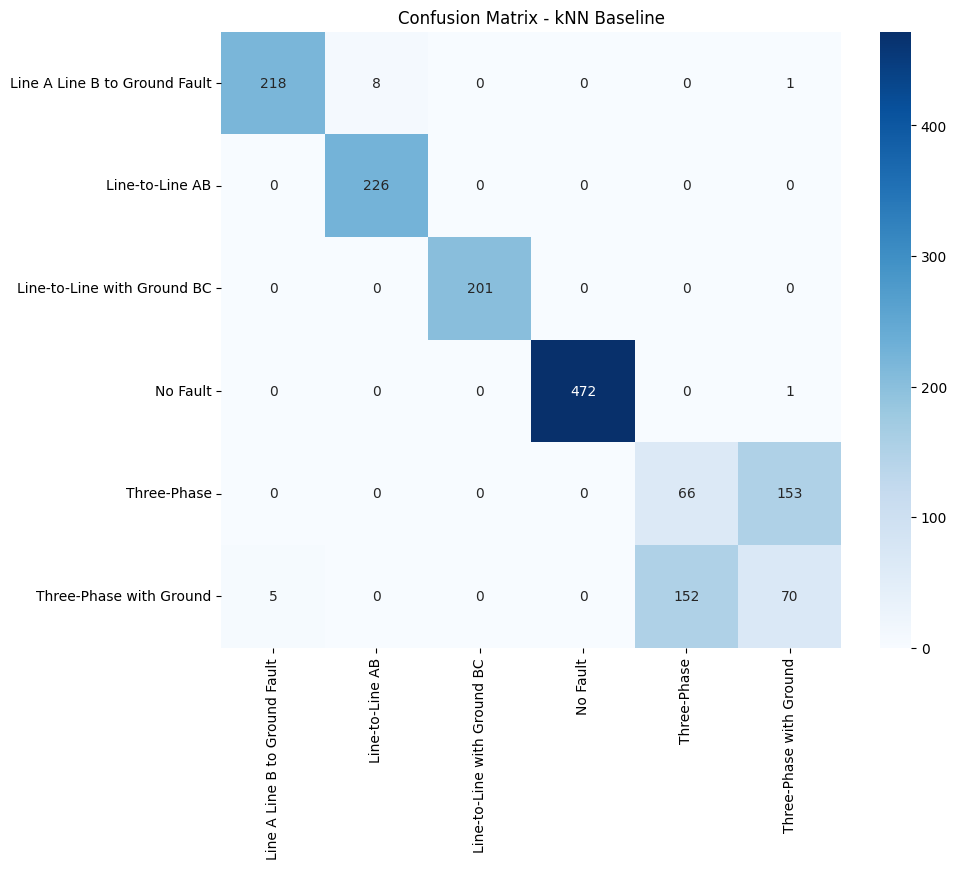

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_base, annot=True, fmt='d', cmap='Blues',
    xticklabels=knn_base.classes_,
    yticklabels=knn_base.classes_
)
plt.title("Confusion Matrix - kNN Baseline")
plt.show()

## Mô hình Optimized - kNN

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_knn = grid_search.best_estimator_


Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [27]:

joblib.dump({
    "best_model": best_knn,
    "grid_search": grid_search,
    "scaler": scaler,
    "best_params": grid_search.best_params_,
    "features": X.columns.tolist()
}, "knn_optimized.pkl")

print("Đã lưu Model")

Đã lưu Model


## Trực quan và Đánh giá Optimized

In [28]:
y_pred_opt = best_knn.predict(X_test_scaled)

optimized_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_opt),
    "F1 Macro": f1_score(y_test, y_pred_opt, average='macro'),
    "Precision Macro": precision_score(y_test, y_pred_opt, average='macro'),
    "Recall Macro": recall_score(y_test, y_pred_opt, average='macro')
}

optimized_metrics

{'Accuracy': 0.8849332485696122,
 'F1 Macro': 0.8651336003483282,
 'Precision Macro': 0.8652091746919334,
 'Recall Macro': 0.8652361170454562}

### Confusion Matrix

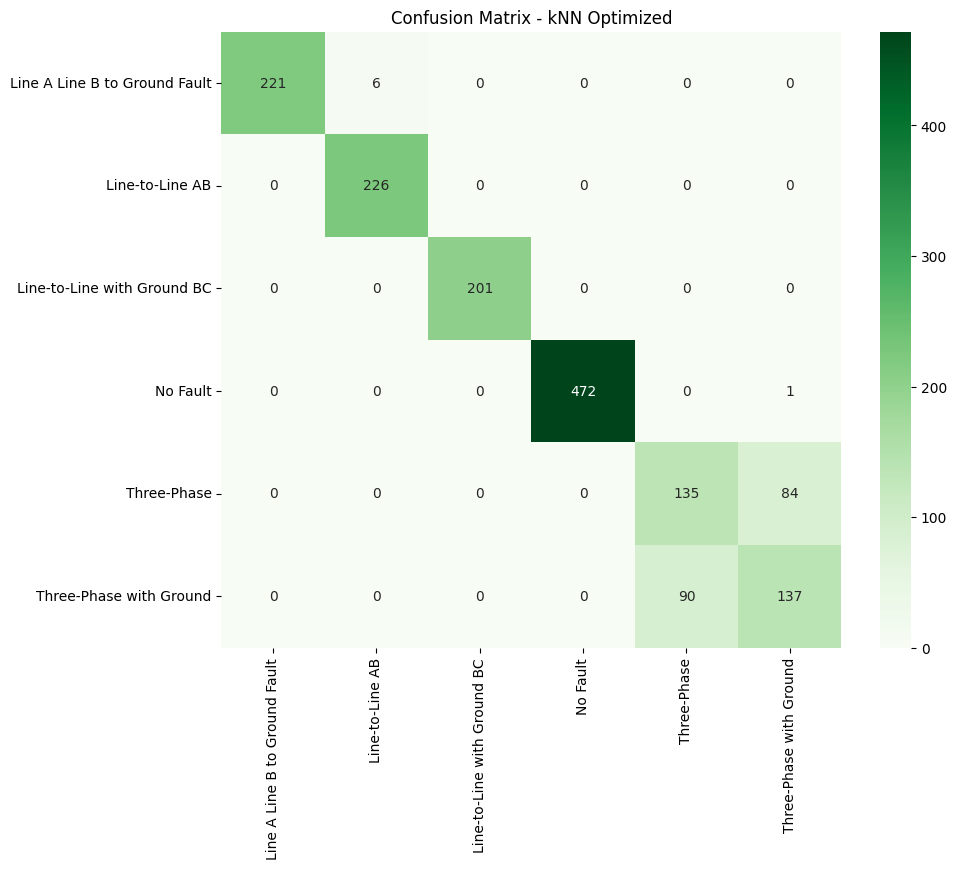

In [29]:
cm_opt = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_opt, annot=True, fmt='d', cmap='Greens',
    xticklabels=best_knn.classes_,
    yticklabels=best_knn.classes_
)
plt.title("Confusion Matrix - kNN Optimized")
plt.show()

## Baseline vs Optimized

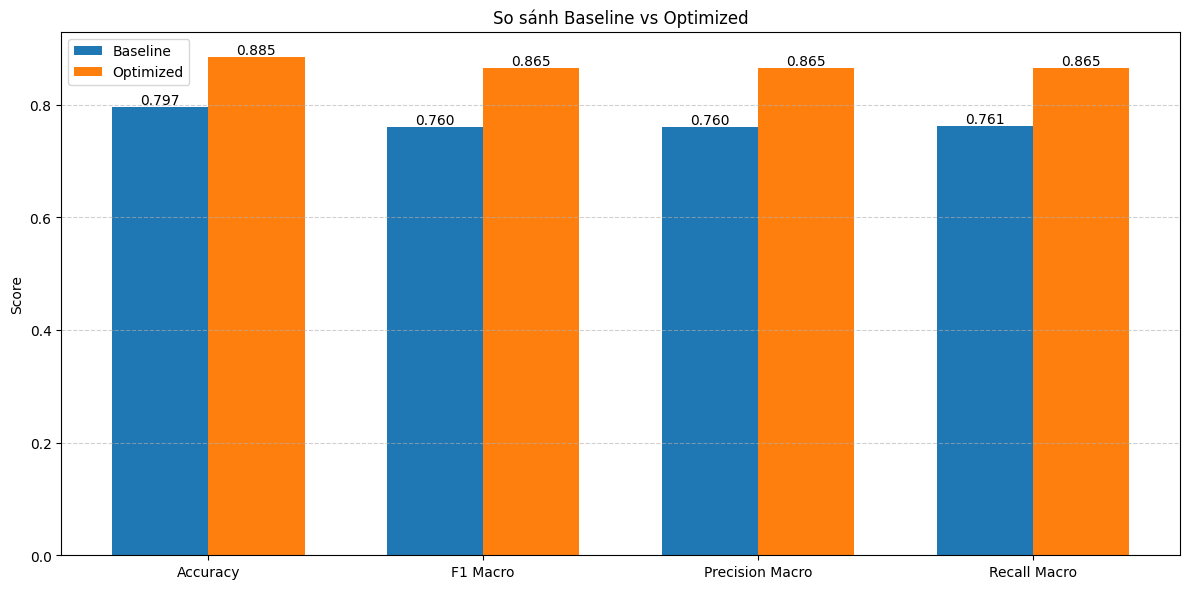

In [30]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "F1 Macro", "Precision Macro", "Recall Macro"]
base_vals = [baseline_metrics[m] for m in metrics]
opt_vals = [optimized_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - width/2, base_vals, width, label='Baseline')
bars2 = plt.bar(x + width/2, opt_vals, width, label='Optimized')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

add_labels(bars1)
add_labels(bars2)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("So sánh Baseline vs Optimized")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Test

In [31]:
import joblib
import pandas as pd
import numpy as np

# ===== Load model =====
knn_data = joblib.load('knn_optimized.pkl')
knn_model = knn_data ["best_model"]

idx = np.random.choice(len(X_test), size=10, replace=False)

X_sample = X_test.iloc[idx]
y_true_sample = y_test.iloc[idx]

X_sample_scaled = scaler.transform(X_sample)

y_pred_sample = knn_model.predict(X_sample_scaled)

demo_df = X_sample.copy()
demo_df["True"] = y_true_sample.values
demo_df["Pred"] = y_pred_sample
demo_df["Correct"] = demo_df["True"] == demo_df["Pred"]

demo_df

,Ia,Ib,Ic,Va,Vb,Vc,True,Pred,Correct
5172,-800.779127,723.529090,77.247773,-0.001984,0.037664,-0.035680,Three-Phase with Ground,Three-Phase with Ground,True
7280,37.539801,47.234868,-87.806582,-0.331432,0.624468,-0.293036,No Fault,No Fault,True
6734,-5.549874,-22.788372,25.142995,0.583810,-0.366985,-0.216826,No Fault,No Fault,True
234,878.738581,54.265665,-0.250291,-0.074063,-0.186499,0.260562,Line-to-Line AB,Line-to-Line AB,True
2149,841.176773,-637.802127,-1.695634,0.009197,-0.222787,0.213590,Line A Line B to Ground Fault,Line A Line B to Ground Fault,True
3231,-29.429588,-479.132521,510.822374,-0.478349,-0.031135,0.509484,Line-to-Line with Ground BC,Line-to-Line with Ground BC,True
777,-520.797755,-69.404603,39.120346,0.339409,-0.333311,-0.006097,Line-to-Line AB,Line-to-Line AB,True
4854,-581.940504,-285.024744,866.963003,-0.041202,0.029227,0.011975,Three-Phase with Ground,Three-Phase with Ground,True
4376,-671.426088,376.764956,295.725495,-0.124796,0.052924,0.071872,Three-Phase with Ground,Three-Phase,False
2143,816.077612,-693.376935,-7.123597,0.005265,-0.193231,0.187966,Line A Line B to Ground Fault,Line A Line B to Ground Fault,True
